# Data Preprocessing 
Load raw data, visualize, map labels, chunk windows, and normalize.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [2]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    create_windows,
    clean_features,

    get_feature_columns,
 )
from data.motion_dataset import MotionDataset

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_types = ["Segment Velocity", "Segment Acceleration"]
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2


# Read data 

In [3]:
print("[phase=data] loading P1 + P2 datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 source
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing.csv"),
]
p1_raw_df = pd.concat(p1_dfs, ignore_index=True)

# P2 source
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing.csv"),
]
p2_raw_df = pd.concat(p2_dfs, ignore_index=True)

# Keep velocity + acceleration only
p1_raw_df = p1_raw_df[p1_raw_df["sensor_type"].isin(sensor_types)]
p2_raw_df = p2_raw_df[p2_raw_df["sensor_type"].isin(sensor_types)]

# Optional video suffix filter
if video_suffix is not None:
    p1_raw_df = p1_raw_df[p1_raw_df["video_id"].str.endswith(video_suffix)]
    p2_raw_df = p2_raw_df[p2_raw_df["video_id"].str.endswith(video_suffix)]

def merge_velocity_and_acceleration(df):
    vel_df = df[df["sensor_type"] == "Segment Velocity"].copy()
    acc_df = df[df["sensor_type"] == "Segment Acceleration"].copy()

    if vel_df.empty or acc_df.empty:
        raise ValueError("Both Segment Velocity and Segment Acceleration rows are required.")

    base_feature_cols = get_feature_columns(vel_df)

    id_cols = [
        c for c in ["video_id", "Frame", "Label", "person_id", "activity_type", "knife_sharpness_score"]
        if c in vel_df.columns
    ]

    vel_df = vel_df[id_cols + base_feature_cols].rename(
        columns={c: f"{c}_vel" for c in base_feature_cols}
    )
    acc_df = acc_df[["video_id", "Frame"] + base_feature_cols].rename(
        columns={c: f"{c}_acc" for c in base_feature_cols}
    )

    merged_df = vel_df.merge(
        acc_df,
        on=["video_id", "Frame"],
        how="inner",
        validate="one_to_one",
    )
    return merged_df, base_feature_cols

p1_df, base_feature_cols = merge_velocity_and_acceleration(p1_raw_df)
p2_df, _ = merge_velocity_and_acceleration(p2_raw_df)

velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]
feature_cols = velocity_feature_cols + acceleration_feature_cols

assert p1_df["Label"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["Label"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
print(f"[phase=data] velocity_features={len(velocity_feature_cols)} acceleration_features={len(acceleration_feature_cols)} total_features={len(feature_cols)}")
p1_df.head()


[phase=data] loading P1 + P2 datasets


C:\Users\PCPV\AppData\Local\Temp\ipykernel_21548\3268270065.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_boning.csv"),
C:\Users\PCPV\AppData\Local\Temp\ipykernel_21548\3268270065.py:7: DtypeWarning: Columns (70) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_slicing.csv"),


[phase=data] p1_rows=266924 p2_rows=208908
[phase=data] velocity_features=66 acceleration_features=66 total_features=132


,video_id,Frame,Label,person_id,activity_type,knife_sharpness_score,L5 x_vel,L5 y_vel,L5 z_vel,L3 x_vel,...,Left Upper Leg z_acc,Left Lower Leg x_acc,Left Lower Leg y_acc,Left Lower Leg z_acc,Left Foot x_acc,Left Foot y_acc,Left Foot z_acc,Left Toe x_acc,Left Toe y_acc,Left Toe z_acc
0,MVN-J-Boning-64-001,0,4,P1,boning,64,0.016263,-0.095142,0.221275,0.016263,...,-1.463229,-1.665037,-2.060481,-1.485525,-2.185359,-1.194785,-1.663235,-2.185359,-1.194785,-1.663235
1,MVN-J-Boning-64-001,1,4,P1,boning,64,0.001253,-0.126477,0.188341,-0.007620,...,-1.230812,-0.752149,-2.689504,-1.314239,-1.060466,-1.162565,-1.845591,-1.064713,-1.147108,-1.845636
2,MVN-J-Boning-64-001,2,4,P1,boning,64,-0.013758,-0.157811,0.155406,-0.031503,...,-1.454299,0.183840,-2.178955,-1.321744,-0.220440,-1.530509,-1.658241,-0.227187,-1.514522,-1.657987
3,MVN-J-Boning-64-001,3,4,P1,boning,64,-0.022041,-0.178102,0.134543,-0.045098,...,-1.521032,0.540981,-0.951495,-1.324380,-0.175790,-1.007643,-1.326566,-0.091278,-0.986575,-1.316862
4,MVN-J-Boning-64-001,4,4,P1,boning,64,-0.020406,-0.179536,0.134429,-0.042620,...,-0.523328,0.754778,-0.402592,-0.509365,0.347853,-0.509991,-0.538392,0.335083,-0.493518,-0.537629


# Visualize Data (Optional)

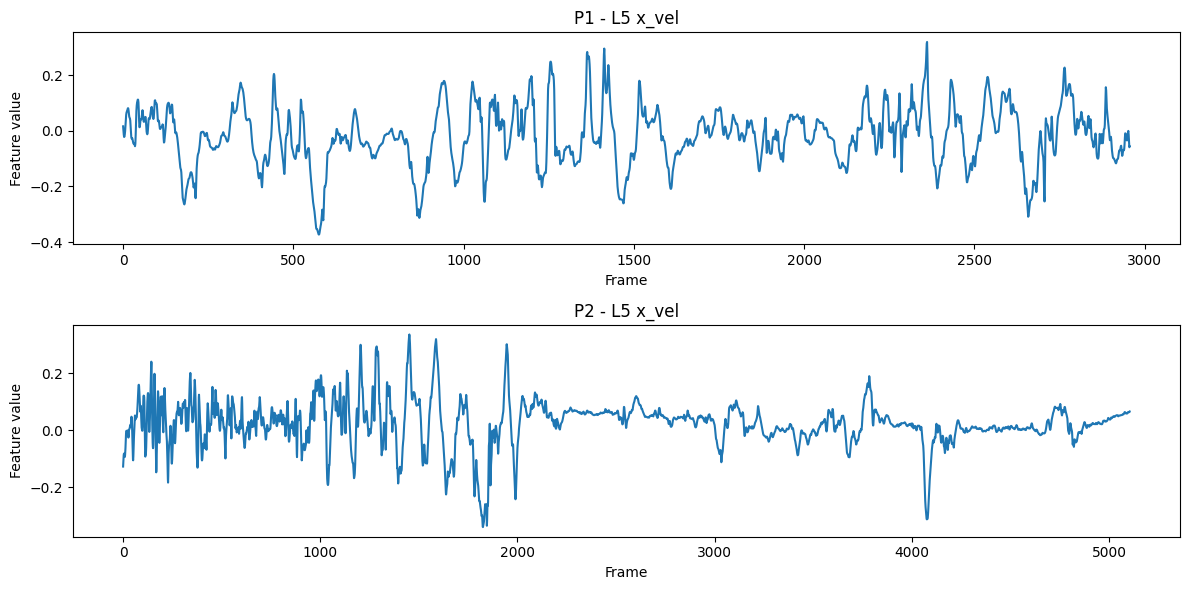

In [4]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x_vel"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["video_id"] == p1_df["video_id"].iloc[0]]
p2_sample = p2_df[p2_df["video_id"] == p2_df["video_id"].iloc[0]]

# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# Process Data: Split Train/Test/Val

In [5]:
import pandas as pd

print("[phase=data] Unique labels and their counts per activity:")

# 1. Combine both datasets to get the overall count
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# 2. Group by activity_type and Label to calculate counts
overall_label_counts = combined_df.groupby(
    ['Label']
).size().reset_index(name='Count')

# 3. Print the detailed breakdown
print(overall_label_counts.to_string(index=False))


[phase=data] Unique labels and their counts per activity:
                    Label  Count
                        0  62948
                        1  13102
                        2  43149
                        3  16984
                        4 213592
                        5  34193
                        6   7162
                        7   4838
                        8  16325
                        0    529
                        1   1566
                        2    587
             2 - Steeling   1469
                        3    479
             3 - Reaching   3282
                        4   5540
              4 - Cutting  24550
                        5    117
              5 - Slicing  18779
7 - Placing/ Manipulating    787
             8 - Dropping   5854


# Relabel

In [6]:
print("[phase=data] Cleaning labels and filtering frames")

label_mapping = {
    '0- Idle': 0,
    '0 - Idle': 0,
    '1- Walking': 1,
    '1 - Walking': 1,
    '2- Steeling': 2,
    '2 - Steeling': 2,
    '3- Reaching': 3,
    '3 - Reaching': 3,
    '4- Cutting': 4,
    '4 - Cutting': 4,
    '4 - Cutting (Big Pieces)': 4,
    '4 - Cutting (Big Piece)': 4,
    '4- Cutting (big piece)': 4,
    '4 - Cutting (offloading bone from Carcass)': 4,
    '5- Dropping': 8,
    '5 - Dropping': 8,
    '5 - Slicing': 5,
    '6 - Pulling': 6,
    '7 - Placing/ Manipulating': 7,
    '8 - Dropping': 8,
}

for df in [p1_df, p2_df]:
    df['Label'] = df['Label'].replace(label_mapping)
    df['Label'] = pd.to_numeric(df['Label'], errors='coerce')
    if df['Label'].isna().any():
        print("[warning] Found non-numeric labels after mapping; dropping NaN labels")
        df.dropna(subset=['Label'], inplace=True)
    df['Label'] = df['Label'].astype('int64')

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

TARGET_COL = 'sharpness_class'
EXCLUDED_LABELS = {0, 1, 2, 3}

combined_df = combined_df[~combined_df['Label'].isin(EXCLUDED_LABELS)].copy()

# Build sharpness_class from knife_sharpness_score if missing.
if 'knife_sharpness_score' not in combined_df.columns:
    raise KeyError("Missing required column 'knife_sharpness_score' to derive sharpness_class")

sharpness_score = pd.to_numeric(combined_df['knife_sharpness_score'], errors='coerce')
missing_score_count = int(sharpness_score.isna().sum())
if missing_score_count > 0:
    print(f"[warning] Found {missing_score_count} invalid knife_sharpness_score values; dropping these rows")
    combined_df = combined_df.loc[sharpness_score.notna()].copy()
    sharpness_score = sharpness_score.loc[sharpness_score.notna()]

combined_df[TARGET_COL] = np.where(
    sharpness_score < 70,
    'blunt',
    np.where(sharpness_score >= 85, 'sharp', 'medium')
)

combined_df[TARGET_COL] = combined_df[TARGET_COL].astype(str).str.strip().str.lower()

print(f"[phase=data] Excluded frame labels: {sorted(EXCLUDED_LABELS)}")
print(f"[phase=data] Remaining rows after filter: {len(combined_df)}")
print("[phase=data] Unique video_id values after filtering:")
unique_video_ids = sorted(combined_df['video_id'].dropna().astype(str).unique().tolist())
print(f"total_video_ids={len(unique_video_ids)}")
for video_id in unique_video_ids:
    print(video_id)

target_counts = combined_df.groupby([TARGET_COL, 'Label']).size().reset_index(name='Count')
print("\n[phase=data] remaining label counts by activity_type:")
print(target_counts.to_string(index=False))

assert len(combined_df) > 0, "No rows left after excluding labels 0,1,2,3"
assert combined_df[TARGET_COL].nunique() > 1, "Need at least 2 activity_type classes for training"

[phase=data] Cleaning labels and filtering frames
[phase=data] Excluded frame labels: [0, 1, 2, 3]
[phase=data] Remaining rows after filter: 331737
[phase=data] Unique video_id values after filtering:
total_video_ids=25
MVN-J-Boning-64-001
MVN-J-Boning-64-002
MVN-J-Boning-64-003
MVN-J-Boning-64-004
MVN-J-Boning-64-005
MVN-J-Boning-64-006
MVN-J-Boning-79-001
MVN-J-Boning-90-001
MVN-J-Boning-90-002
MVN-J-Boning-90-003
MVN-J-Boning-90-004
MVN-J-Slicing-64-001
MVN-J-Slicing-73-001
MVN-J-Slicing-87-001
MVN-S-Boning-63-001
MVN-S-Boning-63-002
MVN-S-Boning-63-003
MVN-S-Boning-76-001
MVN-S-Boning-76-002
MVN-S-Boning-89-001
MVN-S-Boning-89-002
MVN-S-Boning-89-003
MVN-S-Boning-89-004
MVN-S-Slicing-63-001
MVN-S-Slicing-73-001

[phase=data] remaining label counts by activity_type:
sharpness_class  Label  Count
          blunt      4  49826
          blunt      5   8421
          blunt      6    399
          blunt      7   1354
          blunt      8   3968
         medium      4 104600
         m

# Feature Engineering

In [7]:
import numpy as np
import pandas as pd

# Use the filtered/relabeled combined_df from the previous cell.
# Do not rebuild from p1_df/p2_df, otherwise TARGET_COL is lost.

 # Build segment list from base xyz feature names (e.g., "L5 x")
segment_names = []
for col in base_feature_cols:
    segment_name, axis = col.rsplit(" ", 1)
    if axis == "x":
        segment_names.append(segment_name)

# Keep stable order, unique only
segment_names = list(dict.fromkeys(segment_names))

engineered_cols = {}

# Baseline features: 22 velocity magnitude + 22 acceleration magnitude
for seg in segment_names:
    vx_col, vy_col, vz_col = f"{seg} x_vel", f"{seg} y_vel", f"{seg} z_vel"
    ax_col, ay_col, az_col = f"{seg} x_acc", f"{seg} y_acc", f"{seg} z_acc"

    vel_mag_col = f"{seg}_vel_mag"
    acc_mag_col = f"{seg}_acc_mag"

    engineered_cols[vel_mag_col] = np.sqrt(
        combined_df[vx_col] ** 2 + combined_df[vy_col] ** 2 + combined_df[vz_col] ** 2
    )
    engineered_cols[acc_mag_col] = np.sqrt(
        combined_df[ax_col] ** 2 + combined_df[ay_col] ** 2 + combined_df[az_col] ** 2
    )

velocity_mag_feature_cols = [f"{seg}_vel_mag" for seg in segment_names]
acceleration_mag_feature_cols = [f"{seg}_acc_mag" for seg in segment_names]

# Baseline total body energy
energy_terms = []
for seg in segment_names:
    energy_terms.extend([
        combined_df[f"{seg} x_vel"] ** 2,
        combined_df[f"{seg} y_vel"] ** 2,
        combined_df[f"{seg} z_vel"] ** 2,
        combined_df[f"{seg} x_acc"] ** 2,
        combined_df[f"{seg} y_acc"] ** 2,
        combined_df[f"{seg} z_acc"] ** 2,
    ])
engineered_cols["total_body_energy"] = np.sum(np.column_stack(energy_terms), axis=1)

# New feature engineering --------------------------------------------------
arm_joints = [
    seg for seg in segment_names
    if any(k in seg for k in ["Shoulder", "Upper Arm", "Forearm", "Hand"])
]
leg_joints = [
    seg for seg in segment_names
    if any(k in seg for k in ["Upper Leg", "Lower Leg", "Foot", "Toe"])
]
arm_leg_joints = list(dict.fromkeys(arm_joints + leg_joints))

spine_head_joints = [seg for seg in segment_names if seg in ["L5", "L3", "T12", "T8", "Neck", "Head"]]
upper_body_joints = list(dict.fromkeys(spine_head_joints + arm_joints))
lower_body_joints = leg_joints
left_body_joints = [seg for seg in segment_names if seg.startswith("Left ")]
right_body_joints = [seg for seg in segment_names if seg.startswith("Right ")]

# 1) Axis-pair magnitudes for arm+leg joints only (velocity + acceleration)
pair_suffixes = [("x", "y", "xy"), ("x", "z", "xz"), ("y", "z", "yz")]
pair_feature_cols = []
for seg in arm_leg_joints:
    for a1, a2, pair_name in pair_suffixes:
        vel_pair_col = f"{seg}_vel_{pair_name}"
        acc_pair_col = f"{seg}_acc_{pair_name}"

        engineered_cols[vel_pair_col] = np.sqrt(
            combined_df[f"{seg} {a1}_vel"] ** 2 + combined_df[f"{seg} {a2}_vel"] ** 2
        )
        engineered_cols[acc_pair_col] = np.sqrt(
            combined_df[f"{seg} {a1}_acc"] ** 2 + combined_df[f"{seg} {a2}_acc"] ** 2
        )

        pair_feature_cols.extend([vel_pair_col, acc_pair_col])

# 2) Motion energy distribution (upper/lower and left/right)
def group_energy(df, joints):
    if len(joints) == 0:
        return pd.Series(np.zeros(len(df)), index=df.index)
    terms = []
    for seg in joints:
        terms.extend([
            df[f"{seg} x_vel"] ** 2,
            df[f"{seg} y_vel"] ** 2,
            df[f"{seg} z_vel"] ** 2,
            df[f"{seg} x_acc"] ** 2,
            df[f"{seg} y_acc"] ** 2,
            df[f"{seg} z_acc"] ** 2,
        ])
    return np.sum(np.column_stack(terms), axis=1)

upper_energy = group_energy(combined_df, upper_body_joints)
lower_energy = group_energy(combined_df, lower_body_joints)
left_energy = group_energy(combined_df, left_body_joints)
right_energy = group_energy(combined_df, right_body_joints)

engineered_cols["upper_body_energy"] = upper_energy
engineered_cols["lower_body_energy"] = lower_energy
engineered_cols["left_body_energy"] = left_energy
engineered_cols["right_body_energy"] = right_energy

eps = 1e-8
ul_denom = upper_energy + lower_energy + eps
lr_denom = left_energy + right_energy + eps

engineered_cols["upper_energy_ratio"] = upper_energy / ul_denom
engineered_cols["lower_energy_ratio"] = lower_energy / ul_denom
engineered_cols["left_energy_ratio"] = left_energy / lr_denom
engineered_cols["right_energy_ratio"] = right_energy / lr_denom

energy_distribution_feature_cols = [
    "upper_energy_ratio",
    "lower_energy_ratio",
    "left_energy_ratio",
    "right_energy_ratio",
]

# Attach all engineered columns at once to avoid DataFrame fragmentation
combined_df = pd.concat([combined_df, pd.DataFrame(engineered_cols)], axis=1)

# Final training features
feature_cols = (
    velocity_mag_feature_cols
    + acceleration_mag_feature_cols
    + ["total_body_energy"]
    + pair_feature_cols
    + energy_distribution_feature_cols
)

print("[phase=features] Feature engineering complete")
print(f"Baseline velocity magnitude features: {len(velocity_mag_feature_cols)}")
print(f"Baseline acceleration magnitude features: {len(acceleration_mag_feature_cols)}")
print("Baseline total body energy features: 1")
print(f"Axis-pair features (arms+legs, vel+acc, xy/xz/yz): {len(pair_feature_cols)}")
print(f"Energy distribution ratio features: {len(energy_distribution_feature_cols)}")
print(f"Total training features: {len(feature_cols)}")
print("Sample features:", feature_cols[:6], "...", feature_cols[-6:])

# Sanity checks for new distribution features
ul_sum = (combined_df["upper_energy_ratio"] + combined_df["lower_energy_ratio"]).mean()
lr_sum = (combined_df["left_energy_ratio"] + combined_df["right_energy_ratio"]).mean()
print(f"[phase=features] mean(upper+lower ratio)={ul_sum:.6f}")
print(f"[phase=features] mean(left+right ratio)={lr_sum:.6f}")

[phase=features] Feature engineering complete
Baseline velocity magnitude features: 22
Baseline acceleration magnitude features: 22
Baseline total body energy features: 1
Axis-pair features (arms+legs, vel+acc, xy/xz/yz): 96
Energy distribution ratio features: 4
Total training features: 145
Sample features: ['L5_vel_mag', 'L3_vel_mag', 'T12_vel_mag', 'T8_vel_mag', 'Neck_vel_mag', 'Head_vel_mag'] ... ['Left Toe_vel_yz', 'Left Toe_acc_yz', 'upper_energy_ratio', 'lower_energy_ratio', 'left_energy_ratio', 'right_energy_ratio']
[phase=features] mean(upper+lower ratio)=1.000000
[phase=features] mean(left+right ratio)=1.000000


In [8]:
print(p1_df["Label"].dtype)

int64


# Dynamic Windows by Label Transitions

Detect activity label changes (without groupby), count frames per label, visualize one sample, then build dynamic windows.

In [9]:
import pandas as pd

print(f"[phase=runs] Building contiguous runs by video_id + {TARGET_COL} transition")

combined_df = combined_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

runs = []
frame_counts = {}
run_counts = {}

start_idx = 0
current_video = combined_df.loc[0, "video_id"]
current_target = combined_df.loc[0, TARGET_COL]

for i in range(len(combined_df)):
    target_i = combined_df.loc[i, TARGET_COL]
    frame_counts[target_i] = frame_counts.get(target_i, 0) + 1

for i in range(1, len(combined_df)):
    video_i = combined_df.loc[i, "video_id"]
    target_i = combined_df.loc[i, TARGET_COL]

    is_boundary = (video_i != current_video) or (target_i != current_target)

    if is_boundary:
        end_idx = i - 1
        start_frame = int(combined_df.loc[start_idx, "Frame"])
        end_frame = int(combined_df.loc[end_idx, "Frame"])
        run_length = end_idx - start_idx + 1

        runs.append({
            "video_id": current_video,
            "target": current_target,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "run_length": run_length,
        })

        run_counts[current_target] = run_counts.get(current_target, 0) + 1

        start_idx = i
        current_video = video_i
        current_target = target_i

end_idx = len(combined_df) - 1
start_frame = int(combined_df.loc[start_idx, "Frame"])
end_frame = int(combined_df.loc[end_idx, "Frame"])
run_length = end_idx - start_idx + 1
runs.append({
    "video_id": current_video,
    "target": current_target,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "start_frame": start_frame,
    "end_frame": end_frame,
    "run_length": run_length,
})
run_counts[current_target] = run_counts.get(current_target, 0) + 1

print(f"[phase=runs] total_runs={len(runs)}")
print(f"[phase=runs] frame count per {TARGET_COL}:")
for target in sorted(frame_counts):
    print(f"  {target}: {frame_counts[target]}")

print(f"[phase=runs] run count per {TARGET_COL}:")
for target in sorted(run_counts):
    print(f"  {target}: {run_counts[target]}")

runs_df = pd.DataFrame(runs)
print("[phase=runs] run length stats:")
print(runs_df['run_length'].describe(percentiles=[0.5]).to_string())

[phase=runs] Building contiguous runs by video_id + sharpness_class transition
[phase=runs] total_runs=25
[phase=runs] frame count per sharpness_class:
  blunt: 63968
  medium: 148967
  sharp: 118802
[phase=runs] run count per sharpness_class:
  blunt: 11
  medium: 5
  sharp: 9
[phase=runs] run length stats:
count       25.000000
mean     13269.480000
std      14449.350989
min       1170.000000
50%       9686.000000
max      49970.000000


[phase=plot] Plotting one sample video with sharpness_class transitions
[phase=plot] Sample video: MVN-J-Boning-64-001 (1294 frames)


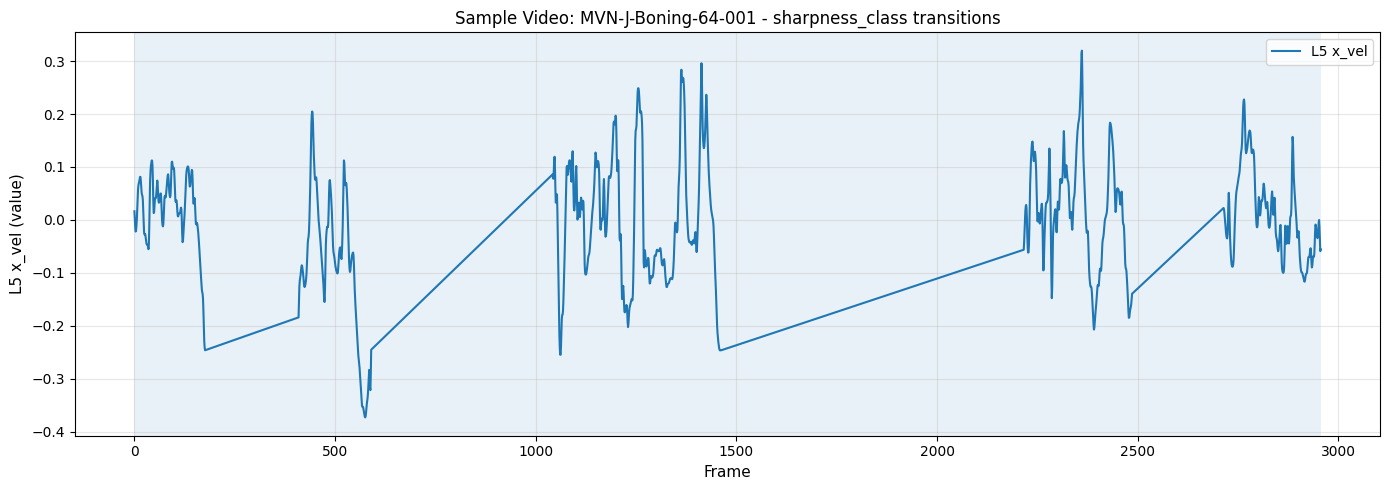

[phase=plot] Red dashed lines indicate {TARGET_COL} transition points.


In [10]:
import matplotlib.pyplot as plt

print(f"[phase=plot] Plotting one sample video with {TARGET_COL} transitions")

sample_video_id = combined_df["video_id"].unique()[0]
sample_df = combined_df[combined_df["video_id"] == sample_video_id].copy()
sample_df = sample_df.sort_values("Frame").reset_index(drop=True)

print(f"[phase=plot] Sample video: {sample_video_id} ({len(sample_df)} frames)")

feature_name = "L5 x_vel"
fig, ax = plt.subplots(figsize=(14, 5))

frames = sample_df["Frame"].values
feature_values = sample_df[feature_name].values
ax.plot(frames, feature_values, linewidth=1.5, label=feature_name)

transition_mask = sample_df[TARGET_COL].ne(sample_df[TARGET_COL].shift())
transitions = sample_df.loc[transition_mask, "Frame"].values[1:]
for t_frame in transitions:
    ax.axvline(x=t_frame, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

previous_transition = frames[0]
for t_frame in transitions:
    ax.axvspan(previous_transition, t_frame, alpha=0.1)
    previous_transition = t_frame
ax.axvspan(previous_transition, frames[-1], alpha=0.1)

ax.set_xlabel("Frame", fontsize=11)
ax.set_ylabel(f"{feature_name} (value)", fontsize=11)
ax.set_title(f"Sample Video: {sample_video_id} - {TARGET_COL} transitions", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("[phase=plot] Red dashed lines indicate {TARGET_COL} transition points.")

# Normalize Data


In [11]:
# Normalization note: with grouped CV, scaling must be fitted inside each fold on fold-train data only
from sklearn.preprocessing import StandardScaler

def summarize_stats(df, cols, prefix):
    stats = {
        "min": df[cols].min().min(),
        "max": df[cols].max().max(),
        "mean": df[cols].mean().mean(),
        "std": df[cols].std().mean(),
    }
    print(
        f"{prefix} -> min: {stats['min']:.6f} | max: {stats['max']:.6f} | "
        f"mean: {stats['mean']:.6f} | std: {stats['std']:.6f}"
    )
    return stats

print("[phase=norm] Fold-safe normalization enabled: scaler will be fit within each CV fold on train windows only")
_ = summarize_stats(combined_df, feature_cols, "Combined (pre-normalization)")

[phase=norm] Fold-safe normalization enabled: scaler will be fit within each CV fold on train windows only
Combined (pre-normalization) -> min: 0.000016 | max: 78372.567467 | mean: 3.746363 | std: 6.932597


## Build Dynamic Windows from Label Transitions


In [12]:
import numpy as np

print(f"[phase=windows] Building windows from contiguous {TARGET_COL} runs with frame skipping")

WINDOW_SIZE = 60
WINDOW_STRIDE = 30
FRAME_SKIP_STEP = 2

X_windows = []
y_windows = []
window_meta = []
window_lengths = []

for run_idx, run in enumerate(runs):
    run_indices = np.arange(run["start_idx"], run["end_idx"] + 1)
    sampled_indices = run_indices[::FRAME_SKIP_STEP]

    if len(sampled_indices) == 0:
        continue

    if len(sampled_indices) <= WINDOW_SIZE:
        idx_chunk = sampled_indices
        X_windows.append(combined_df.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["target"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "target": run["target"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })
        continue

    starts = list(range(0, len(sampled_indices) - WINDOW_SIZE + 1, WINDOW_STRIDE))

    for start in starts:
        idx_chunk = sampled_indices[start:start + WINDOW_SIZE]
        X_windows.append(combined_df.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["target"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "target": run["target"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })

    last_covered = starts[-1] + WINDOW_SIZE
    if last_covered < len(sampled_indices):
        idx_chunk = sampled_indices[last_covered:]
        X_windows.append(combined_df.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(run["target"])
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "target": run["target"],
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
        })

y_windows = np.array(y_windows, dtype=object)
window_meta_df = pd.DataFrame(window_meta)

window_count_per_target = {}
for target in y_windows.tolist():
    window_count_per_target[target] = window_count_per_target.get(target, 0) + 1

print(f"[phase=windows] total_windows={len(X_windows)}")
print(f"[phase=windows] windows per {TARGET_COL}:")
for target in sorted(window_count_per_target):
    print(f"  {target}: {window_count_per_target[target]}")

window_lengths_np = np.array(window_lengths)
short_count = int((window_lengths_np < WINDOW_SIZE).sum())
print(f"[phase=windows] short_windows(<{WINDOW_SIZE})={short_count}")
print(f"[phase=windows] window length min/median/max = {window_lengths_np.min()}/{int(np.median(window_lengths_np))}/{window_lengths_np.max()}")

[phase=windows] Building windows from contiguous sharpness_class runs with frame skipping
[phase=windows] total_windows=5517
[phase=windows] windows per sharpness_class:
  blunt: 1061
  medium: 2479
  sharp: 1977
[phase=windows] short_windows(<60)=25
[phase=windows] window length min/median/max = 1/60/60


In [13]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

print("[phase=split] Build 10-fold StratifiedGroupKFold splits by video_id")

def pad_windows_to_60(window_list, target_len=60):
    padded = []
    for arr in window_list:
        if arr.shape[0] == target_len:
            padded.append(arr)
        elif arr.shape[0] < target_len:
            pad_rows = target_len - arr.shape[0]
            pad_block = np.zeros((pad_rows, arr.shape[1]), dtype=arr.dtype)
            padded.append(np.vstack([arr, pad_block]))
        else:
            padded.append(arr[:target_len])
    return np.stack(padded, axis=0)

X_all = pad_windows_to_60(X_windows, target_len=60).astype(np.float32)
groups = window_meta_df["video_id"].astype(str).to_numpy()

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_windows).astype(np.int64)

unique_groups = np.unique(groups)
assert len(unique_groups) >= 10, f"Need at least 10 unique video_id groups, found {len(unique_groups)}"

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
fold_splits = list(cv.split(X_all, y_all, groups=groups))

print(f"[phase=split] X_all shape: {X_all.shape}")
print(f"[phase=split] y_all shape: {y_all.shape}")
print(f"[phase=split] unique video_id groups: {len(unique_groups)}")
print(f"[phase=split] label classes: {label_encoder.classes_.tolist()}")
print(f"[phase=split] total folds: {len(fold_splits)}")

[phase=split] Build 10-fold StratifiedGroupKFold splits by video_id
[phase=split] X_all shape: (5517, 60, 145)
[phase=split] y_all shape: (5517,)
[phase=split] unique video_id groups: 25
[phase=split] label classes: ['blunt', 'medium', 'sharp']
[phase=split] total folds: 10


# Improvements


## Train Test Split

In [14]:
print("[phase=split] Fold audit: leakage check + class balance per fold")

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    train_groups = set(groups[train_idx].tolist())
    val_groups = set(groups[val_idx].tolist())
    overlap = train_groups.intersection(val_groups)
    assert len(overlap) == 0, f"Leakage detected in fold {fold_idx}: overlapping video_ids={overlap}"

    train_counts = np.bincount(y_all[train_idx], minlength=len(label_encoder.classes_))
    val_counts = np.bincount(y_all[val_idx], minlength=len(label_encoder.classes_))

    print(f"Fold {fold_idx:02d} | train_windows={len(train_idx)} val_windows={len(val_idx)} "
          f"| train_videos={len(train_groups)} val_videos={len(val_groups)}")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        print(f"  class={class_name:<8} train={int(train_counts[class_idx]):>5} val={int(val_counts[class_idx]):>5}")

[phase=split] Fold audit: leakage check + class balance per fold
Fold 01 | train_windows=4645 val_windows=872 | train_videos=22 val_videos=3
  class=blunt    train= 1021 val=   40
  class=medium   train= 2479 val=    0
  class=sharp    train= 1145 val=  832
Fold 02 | train_windows=4748 val_windows=769 | train_videos=23 val_videos=2
  class=blunt    train= 1028 val=   33
  class=medium   train= 1743 val=  736
  class=sharp    train= 1977 val=    0
Fold 03 | train_windows=4910 val_windows=607 | train_videos=22 val_videos=3
  class=blunt    train= 1025 val=   36
  class=medium   train= 1957 val=  522
  class=sharp    train= 1928 val=   49
Fold 04 | train_windows=5083 val_windows=434 | train_videos=22 val_videos=3
  class=blunt    train= 1023 val=   38
  class=medium   train= 2201 val=  278
  class=sharp    train= 1859 val=  118
Fold 05 | train_windows=5146 val_windows=371 | train_videos=23 val_videos=2
  class=blunt    train=  934 val=  127
  class=medium   train= 2479 val=    0
  class=s

## Loss Function (Focal Loss)

In [15]:
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        focal = self.alpha * ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction="mean")
print("[phase=loss] Using FocalLoss (alpha=0.25, gamma=2.0) for 3-class sharpness classification")

[phase=loss] Using FocalLoss (alpha=0.25, gamma=2.0) for 3-class sharpness classification


## Class Imbalance Handling

In [16]:
print("[phase=labels] Global encoded activity_type labels for CV")
print("classes:", label_encoder.classes_.tolist())
class_vals, class_counts = np.unique(y_all, return_counts=True)
print("global class counts:", dict(zip(class_vals.tolist(), class_counts.tolist())))

[phase=labels] Global encoded activity_type labels for CV
classes: ['blunt', 'medium', 'sharp']
global class counts: {0: 1061, 1: 2479, 2: 1977}


In [17]:
print("[phase=dataset] Initialize containers for grouped CV")
cv_fold_metrics = []
oof_true = []
oof_pred = []

[phase=dataset] Initialize containers for grouped CV


# Model Building

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm # Optional: for progress bars during epochs

print("[phase=model] Defining BiLSTM Architecture")

# 1. Define the BiLSTM Model Class
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super(ActivityBiLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Single FC block: BN -> Linear -> Dropout -> ReLU
        self.fc_bn = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # Final output layer
        self.fc_out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length/window_size, input_size/features)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Temporal pooling over time dimension (mean pooling)
        # out shape: (batch_size, seq_len, hidden_size * 2)
        out = out.mean(dim=1)
        # out = out[:, -1, :]

        # FC block
        out = self.fc_bn(out)
        out = self.fc(out)
        out = self.dropout(out)
        out = self.relu(out)

        # Final output layer
        out = self.fc_out(out)
        return out



[phase=model] Defining BiLSTM Architecture


# Hyperparameters

In [19]:
# Hyperparameters for each fold
input_size = X_all.shape[-1]
num_classes = len(label_encoder.classes_)

hidden_size = 128
num_layers = 1
dropout = 0.4
learning_rate = 1e-4
weight_decay = 1e-5
batch_size = 32
num_epochs = 30
early_stopping_patience = 10

print(f"[phase=model] CV params: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, num_classes={num_classes}")
print(f"[phase=model] training params: lr={learning_rate}, weight_decay={weight_decay}, batch_size={batch_size}, epochs={num_epochs}")

[phase=model] CV params: input_size=145, hidden_size=128, num_layers=1, num_classes=3
[phase=model] training params: lr=0.0001, weight_decay=1e-05, batch_size=32, epochs=30


# Training

In [20]:
# 10-fold train loop with fold-safe scaling, early stopping, checkpoint, and ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

total_folds = len(fold_splits)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    print(f"\n[phase=cv] ===== Fold {fold_idx}/{total_folds} =====")

    X_train_fold = X_all[train_idx].copy()
    X_val_fold = X_all[val_idx].copy()
    y_train_fold = y_all[train_idx].copy()
    y_val_fold = y_all[val_idx].copy()

    fold_train_groups = set(groups[train_idx].tolist())
    fold_val_groups = set(groups[val_idx].tolist())
    overlap = fold_train_groups.intersection(fold_val_groups)
    assert len(overlap) == 0, f"Leakage in fold {fold_idx}: {overlap}"

    n_features = X_train_fold.shape[-1]
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold.reshape(-1, n_features)).reshape(X_train_fold.shape).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold.reshape(-1, n_features)).reshape(X_val_fold.shape).astype(np.float32)

    X_train_t = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_fold, dtype=torch.long)
    X_val_t = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_fold, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    model = ActivityBiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    prev_lr = optimizer.param_groups[0]['lr']
    checkpoint_path = PROJECT_ROOT / "notebook" / f"best_bilstm_sharpness_fold_{fold_idx}.pt"

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_acc += accuracy_from_logits(logits, yb) * xb.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_acc += accuracy_from_logits(logits, yb) * xb.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc /= len(val_loader.dataset)

        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != prev_lr:
            print(f"[fold={fold_idx}][lr] {prev_lr:.6f} -> {new_lr:.6f}")
            prev_lr = new_lr

        print(f"Fold {fold_idx:02d} Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"[fold={fold_idx}] Early stopping triggered.")
                break

    if checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    model.eval()
    fold_preds = []
    fold_targets = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            fold_preds.append(preds)
            fold_targets.append(yb.numpy())

    fold_preds = np.concatenate(fold_preds)
    fold_targets = np.concatenate(fold_targets)
    oof_pred.append(fold_preds)
    oof_true.append(fold_targets)

    cv_fold_metrics.append({
        "fold": fold_idx,
        "train_windows": int(len(train_idx)),
        "val_windows": int(len(val_idx)),
        "best_val_loss": float(best_val_loss),
        "best_val_acc": float(best_val_acc),
    })

cv_results_df = pd.DataFrame(cv_fold_metrics)
print("\n[phase=cv] Per-fold results:")
print(cv_results_df.to_string(index=False))
print("\n[phase=cv] Aggregate:")
print(f"mean_val_loss={cv_results_df['best_val_loss'].mean():.4f} ± {cv_results_df['best_val_loss'].std():.4f}")
print(f"mean_val_acc ={cv_results_df['best_val_acc'].mean():.4f} ± {cv_results_df['best_val_acc'].std():.4f}")


[phase=cv] ===== Fold 1/10 =====
Fold 01 Epoch 01 | Train Loss: 0.1010 | Train Acc: 0.5600 | Val Loss: 0.3356 | Val Acc: 0.0229
Fold 01 Epoch 02 | Train Loss: 0.0877 | Train Acc: 0.6151 | Val Loss: 0.3952 | Val Acc: 0.0287
Fold 01 Epoch 03 | Train Loss: 0.0799 | Train Acc: 0.6405 | Val Loss: 0.4317 | Val Acc: 0.0275
Fold 01 Epoch 04 | Train Loss: 0.0724 | Train Acc: 0.6751 | Val Loss: 0.4641 | Val Acc: 0.0333
[fold=1][lr] 0.000100 -> 0.000050
Fold 01 Epoch 05 | Train Loss: 0.0677 | Train Acc: 0.6870 | Val Loss: 0.5810 | Val Acc: 0.0218
Fold 01 Epoch 06 | Train Loss: 0.0616 | Train Acc: 0.7210 | Val Loss: 0.5665 | Val Acc: 0.0298
Fold 01 Epoch 07 | Train Loss: 0.0585 | Train Acc: 0.7257 | Val Loss: 0.5848 | Val Acc: 0.0321
Fold 01 Epoch 08 | Train Loss: 0.0555 | Train Acc: 0.7425 | Val Loss: 0.6054 | Val Acc: 0.0321
[fold=1][lr] 0.000050 -> 0.000025
Fold 01 Epoch 09 | Train Loss: 0.0536 | Train Acc: 0.7572 | Val Loss: 0.6956 | Val Acc: 0.0264
Fold 01 Epoch 10 | Train Loss: 0.0510 | Tra

# Evaluation

[phase=eval] Aggregated OOF evaluation over 10 folds


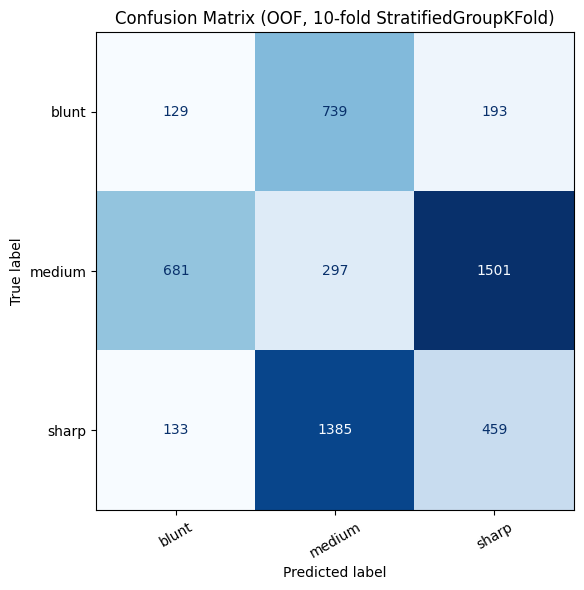

In [21]:
# Aggregated out-of-fold evaluation
print("[phase=eval] Aggregated OOF evaluation over 10 folds")

if len(oof_true) > 0:
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_true = np.concatenate(oof_true).astype(int)
    y_pred = np.concatenate(oof_pred).astype(int)

    labels = list(range(num_classes))
    class_names = label_encoder.classes_.tolist()

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d", xticks_rotation=30)
    ax.set_title("Confusion Matrix (OOF, 10-fold StratifiedGroupKFold)")
    plt.tight_layout()
    plt.show()
else:
    print("[warning] No OOF predictions found.")

In [22]:
import numpy as np
import pandas as pd

print("[phase=eval] Class distribution summary from OOF predictions")

if len(oof_true) > 0:
    y_true = np.concatenate(oof_true).astype(int)
    total = len(y_true)
    counts = pd.Series(y_true).value_counts().sort_index()

    rows = []
    for idx, class_name in enumerate(label_encoder.classes_):
        cnt = int(counts.get(idx, 0))
        pct = (cnt / total * 100.0) if total > 0 else 0.0
        rows.append({
            "encoded_id": idx,
            "activity_type": class_name,
            "oof_windows": cnt,
            "oof_pct": f"{pct:.1f}%",
        })

    print(pd.DataFrame(rows).to_string(index=False))
    print("\n[phase=eval] CV fold metrics (mean Â± std):")
    print(f"val_loss: {cv_results_df['best_val_loss'].mean():.4f} Â± {cv_results_df['best_val_loss'].std():.4f}")
    print(f"val_acc : {cv_results_df['best_val_acc'].mean():.4f} Â± {cv_results_df['best_val_acc'].std():.4f}")
else:
    print("[warning] OOF arrays are empty. Run the CV training cell first.")

[phase=eval] Class distribution summary from OOF predictions
 encoded_id activity_type  oof_windows oof_pct
          0         blunt         1061   19.2%
          1        medium         2479   44.9%
          2         sharp         1977   35.8%

[phase=eval] CV fold metrics (mean Â± std):
val_loss: 0.2048 Â± 0.0776
val_acc : 0.2027 Â± 0.2198
